# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *(replace with your name)*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [76]:
# Your imports here
import pandas as pd
import numpy as np
import os
import PIL
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [77]:
# Load train.csv here
# Load and process data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [78]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [79]:
# Write your image-loading function here
# Normalize pixel values (0-255) -> (0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# One-hot encode labels (0-9)
#y_train = to_categorical(y_train, 10)
#y_test = to_categorical(y_test, 10)

In [80]:
# Build X and y, then split into train/test here
y_train = to_categorical(y_train, 10)


In [81]:
y_train

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [82]:
y_test = to_categorical(y_test, 10)

*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [83]:
# Build your CNN model here
model = Sequential()

# 1st CNN layer with filters = 32, filter_size = 3
model.add(Conv2D(32, kernel_size = 3, activation= 'relu', input_shape = (28, 28, 1)))

# 2nd CNN layer with filters = 64, filter_size = 3
model.add(Conv2D(64, kernel_size = 3, activation= 'relu'))

# Pooling Layer - max pooling, pooling filter size 2 x 2 and stride = 2
model.add(MaxPooling2D(pool_size = (2, 2), strides = 2))

#Flatten the feature maps
model.add(Flatten())

# Fully connected output layer
model.add(Dense(10, activation = 'softmax'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
# Compile your model here
model.compile(optimizer= "adam", loss="categorical_crossentropy", metrics=["accuracy"])


*Your architecture justification (one paragraph):*




---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [85]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

In [86]:
# Train your model here (save the result as `history`)
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
    )

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 128s 84ms/step - accuracy: 0.8554 - loss: 0.4066 - val_accuracy: 0.8949 - val_loss: 0.2921
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 144s 85ms/step - accuracy: 0.9032 - loss: 0.2728 - val_accuracy: 0.9087 - val_loss: 0.2565
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 137s 82ms/step - accuracy: 0.9194 - loss: 0.2258 - val_accuracy: 0.9137 - val_loss: 0.2458
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 140s 81ms/step - accuracy: 0.9316 - loss: 0.1916 - val_accuracy: 0.9146 - val_loss: 0.2429
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 146s 83ms/step - accuracy: 0.9405 - loss: 0.1644 - val_accuracy: 0.9195 - val_loss: 0.2322
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 121s 80ms/step - accuracy: 0.9486 - loss: 0.1418 - val_accuracy: 0.9195 - val_loss: 0.2391
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 149s 85ms/step - accuracy: 0.9556 - loss: 0.1218 - val_accuracy: 0.9183 - val_loss: 0.2647
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 138s 82ms/step - accuracy: 

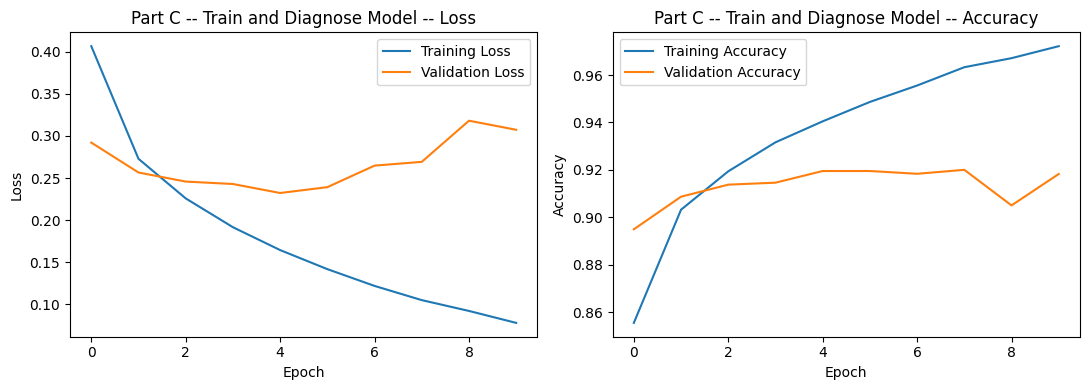

In [87]:
# Plot training vs. validation loss and accuracy here

plot_history(history, "Part C -- Train and Diagnose Model", show_accuracy=True)

*Your fit diagnosis, with specific evidence from your curve:*
The diagnosis is the model is **Overfitting**. This is because after around 5 epochs the validation loss sharply rises up while the training loss is still going down. This creates a huge gap between the traning and validation loss which is evidence that the model is Overfitting.



In [88]:
# Evaluate on the test set and report accuracy here
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9116 - loss: 0.3186
Test Accuracy:  0.9115999937057495


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:* I am choosing to apply Propout and Early Stopping because the model is overfitting so I think Dropping some features will keep the model from fitting too much to the training data. I also think early dropping will be helpful because the epoch 1-5 was pretty good but epoch 5-10 the model started to drastically overfit the data so stopping the model early should help our model increase in accuracy.




In [90]:
import keras_tuner as kt

n_features = x_train.shape[1] * x_train.shape[2]
n_classes = y_train.shape[1]

x_train_flat = x_train.reshape(-1, n_features)

def build_model_with_regularization(hp):
  model = tf.keras.Sequential([
    tf.keras.layers.Dense(
    hp.Int("hidden1", min_value=16, max_value=128, step=16),
    activation="relu", input_shape=(n_features,)
    ),
    tf.keras.layers.Dropout(hp.Float("dropout1", min_value=0.1, max_value=0.5, step=0.1)),
    tf.keras.layers.Dense(
      hp.Int("hidden2", min_value=8, max_value=64, step=8),
      activation="relu"
    ),
    tf.keras.layers.Dropout(hp.Float("dropout2", min_value=0.1, max_value=0.5, step=0.1)),
    tf.keras.layers.Dense(n_classes, activation="softmax")
  ])
  model.compile(
    optimizer=tf.keras.optimizers.Adam(
      hp.Choice("learning_rate", [0.001, 0.01, 0.1])
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
  )
  return model

tuner_regularized = kt.RandomSearch(
  build_model_with_regularization,
  objective="val_loss",
  max_trials=5,
  overwrite=True,
  directory='my_dir',
  project_name='wine_quality_regularized'
)

# Define Early Stopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tuner_regularized.search(
  x_train_flat, y_train, # Use x_train_flat for flattened input
  validation_split=0.2, epochs=100, verbose=0, callbacks=[early_stop]
)

best_model_regularized = tuner_regularized.get_best_models(num_models=1)[0]
best_hp_regularized = tuner_regularized.get_best_hyperparameters(1)[0]
best_trial_regularized = tuner_regularized.oracle.get_best_trials(num_trials=1)[0]
best_val_loss_regularized = best_trial_regularized.score

print("Best hyperparameters with regularization:", best_hp_regularized.values)
print(f"Best Validation Loss with regularization: {best_val_loss_regularized:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best hyperparameters with regularization: {'hidden1': 48, 'dropout1': 0.5, 'hidden2': 64, 'dropout2': 0.1, 'learning_rate': 0.001}
Best Validation Loss with regularization: 0.4282


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


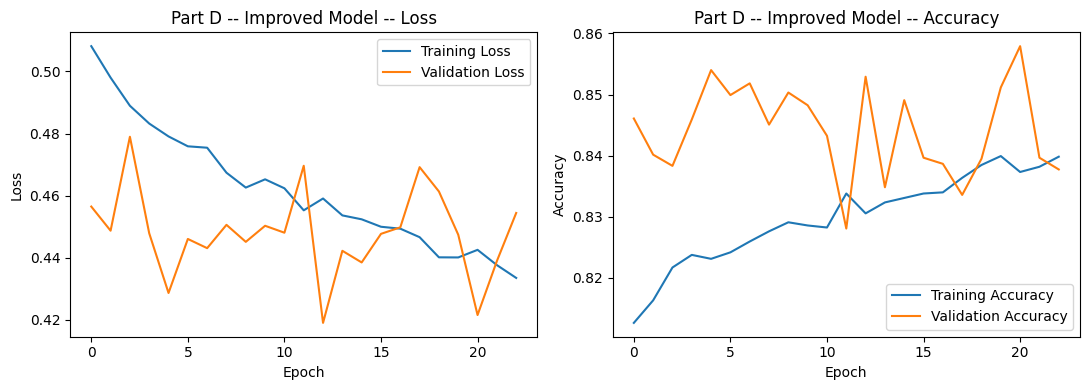

In [91]:
# Train your improved model here

history_regularized = best_model_regularized.fit(
    x_train_flat, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)

plot_history(history_regularized, "Part D -- Improved Model", show_accuracy=True)

---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy |.912|.850|
| Fit pattern (good/over/under) |over |over |
| What changed | | The improved CNN had worse accuracy|

Report a confusion matrix for your improved model.

Baseline Model (Keras evaluate) Test Accuracy: 0.912
Baseline Model (Keras evaluate) Test Loss: 0.319
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step
Part E -- Baseline Test Accuracy (sklearn): 0.912


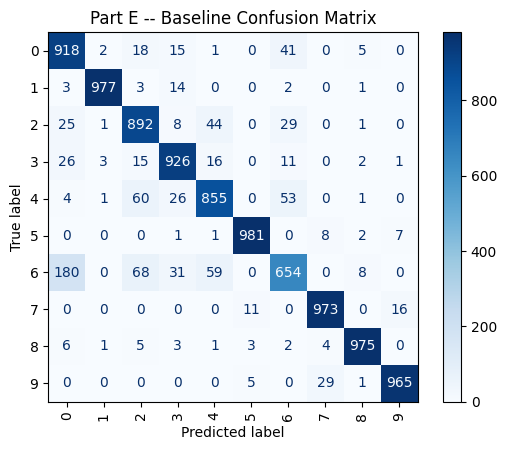

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

loss_eval, acc_eval = model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline Model (Keras evaluate) Test Accuracy: {acc_eval:.3f}")
print(f"Baseline Model (Keras evaluate) Test Loss: {loss_eval:.3f}")

base_model_probs = model.predict(x_test)
base_model_preds_sparse = np.argmax(base_model_probs, axis=1)

y_test_sparse = np.argmax(y_test, axis=1)

base_model_acc = accuracy_score(y_test_sparse, base_model_preds_sparse)
print(f"Part E -- Baseline Test Accuracy (sklearn): {base_model_acc:.3f}")

base_model_cm = confusion_matrix(y_test_sparse, base_model_preds_sparse)
fashion_mnist_labels = [str(i) for i in range(10)]
ConfusionMatrixDisplay(base_model_cm, display_labels=fashion_mnist_labels).plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Part E -- Baseline Confusion Matrix")
plt.show()


Part E -- Improved Model Confusion Matrix
Improved Model (Keras evaluate) Test Accuracy: 0.850
Improved Model (Keras evaluate) Test Loss: 0.436
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


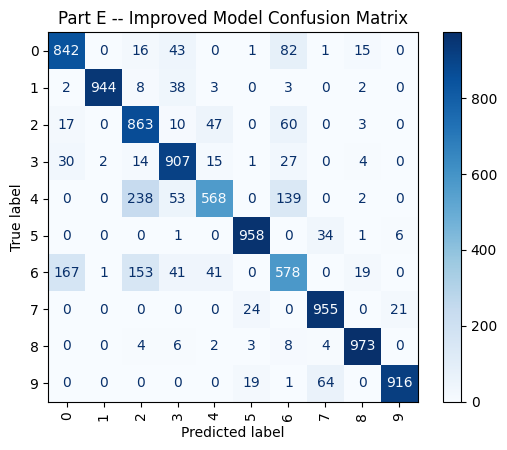

In [93]:
# Improved Model Evaluation
print("\nPart E -- Improved Model Confusion Matrix")
if not best_model_regularized.optimizer:
    best_model_regularized.compile(
        optimizer=tf.keras.optimizers.Adam(best_hp_regularized.get('learning_rate')),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

test_loss_improved, test_acc_improved = best_model_regularized.evaluate(x_test_flat, y_test, verbose=0)
print(f"Improved Model (Keras evaluate) Test Accuracy: {test_acc_improved:.3f}")
print(f"Improved Model (Keras evaluate) Test Loss: {test_loss_improved:.3f}")


improved_model_probs = best_model_regularized.predict(x_test_flat)
improved_model_preds_sparse = np.argmax(improved_model_probs, axis=1)


improved_model_acc = accuracy_score(y_test_sparse, improved_model_preds_sparse)



improved_model_cm = confusion_matrix(y_test_sparse, improved_model_preds_sparse)
ConfusionMatrixDisplay(improved_model_cm, display_labels=fashion_mnist_labels).plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Part E -- Improved Model Confusion Matrix")
plt.show()

*Your discussion of the confusion matrix:*
It looks like both baseline and improved model struggled with the clothing item 6 because the baseline incorrectly guessed cloth item 0, 180 times and the improved model guessed cloth item 0 167 times when the two models should have predicted cloth item 6. It also looked like the improved model sruggled witth guessing 6 and 4 by inaccuratly predicting 2, which was worse then the baseline. The improved model also struggled with guessing 4 as it would falsely guess six 139 times.



---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

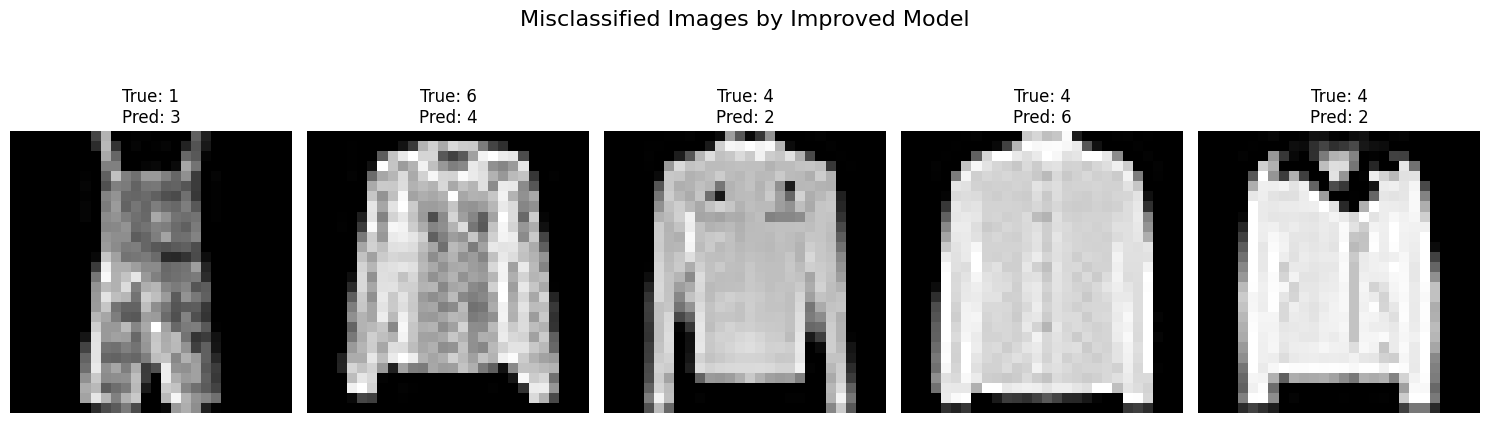

In [94]:
# Get misclassified indices
misclassified_indices = np.where(improved_model_preds_sparse != y_test_sparse)[0]

# Select up to 5 random misclassified images
num_to_display = min(5, len(misclassified_indices))
np.random.seed(42) # for reproducibility
sampled_misclassified_indices = np.random.choice(misclassified_indices, num_to_display, replace=False)

plt.figure(figsize=(15, 5))
for i, index in enumerate(sampled_misclassified_indices):
    plt.subplot(1, num_to_display, i + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    true_label = fashion_mnist_labels[y_test_sparse[index]]
    predicted_label = fashion_mnist_labels[improved_model_preds_sparse[index]]
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')
plt.suptitle("Misclassified Images by Improved Model", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

*Your observations about the misclassified images:*
It appears the model struggles with differentiating between visually similar clothing items, for example confusing different types of upper body garments like coats, shirts, and pullovers. There's also some confusion between trousers and similar bottom-wear items. The images themselves do not show obvious visual anomalies like poor lighting or unusual angles, suggesting the challenge lies in the subtle distinctions between categories.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.